
# Implementation of a Neural Network for Iris dataset classification

This notebook implements a multilayer neural network for classifying flower species in the Iris dataset.

The code is modularized into functions to facilitate understanding and step-by-step execution.


## Introduction <a name="introduction"></a>

In this lab we build a simple Neural Network, implementing every fuunction from scratch.

The problem to be solved is the identification (*classification*, *prediction*) of the species of an Iris flower using the dimensions of the petals and the sepals. The `Iris` dataset we will use was introduced by R.A. Fisher to illustrate his works on Linear Discriminant Analysis.

We will follow a sequence of steps that align well with the process of building and validating a ML model.

- The first part, does not have to do with the model but with the data preparation for modelling
- Next we build the functions for the NN and train in 
- Finally the prformance of the model is checked with the test data

Many of the functions are available in high level libraries -like Tensorflow, Scikit-Learn or Caret- but, for illustration purposes they will be written from scratch.


## Importing libraries

In [131]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


## Load and preprocess data

### Reading the data

In [132]:
#read data from csv
iris = pd.read_csv("data/IrisData1.csv")
selected_rows = [0, 1, 50, 51, 100, 101]
print(iris.iloc[selected_rows])


     Sepal_Length  Sepal_Width  Petal_Length  Petal_Width          Species
0             5.1          3.5           1.4          0.2      Iris-setosa
1             4.9          3.0           1.4          0.2      Iris-setosa
50            7.0          3.2           4.7          1.4  Iris-versicolor
51            6.4          3.2           4.5          1.5  Iris-versicolor
100           6.3          3.3           6.0          2.5   Iris-virginica
101           5.8          2.7           5.1          1.9   Iris-virginica


### Dataset verification

A standard step in the Data Analysis pipeline is to check the data, in order to detect possible wrong or problematic values such as missing data, outliers, mistakes (ex. negative length) etc.

While this is very context dependent a function to automate the checking is defined and applied below.

In [133]:
#Check the dataset to make sure no data is missing and Check the class labels
def verify_dataset(data):
  #if any of the rows have missing value return datas missing
  data_found = 1
  for each_column in data.columns:
    if data[each_column].isnull().any():
            print("Data missing in Column " + each_column)
            #if any rows are not missing return Dataset is complete. No missing value
            quit()
    if data_found == 1:
        print("Dataset is complete. No missing values. Ok")
    return

verify_dataset(iris)

Dataset is complete. No missing values. Ok


### One hot encoding function

In the **Iris dataset**, the target variable `Species` consists of three categorical classes:

- *Iris-setosa*
- *Iris-versicolor*
- *Iris-virginica*

Machine learning models, especially neural networks, require numerical inputs. However, categorical values like `"Iris-setosa"` cannot be directly used in mathematical computations. In cases like this a common strategy is tio use *one_hot encoding* 

One-hot encoding is a technique used to convert categorical labels into a numerical format that can be processed by machine learning models. In this method, each category is represented as a binary vector where only one element is `1`, and all others are `0`.

One-hot encoding transforms them into numerical representations like:

| Species          | One-Hot Encoding |
|------------------|-----------------|
| Iris-setosa     | `[1, 0, 0]`       |
| Iris-versicolor | `[0, 1, 0]`       |
| Iris-virginica  | `[0, 0, 1]`       |

This ensures that the model **does not assign an ordinal relationship** between categories (e.g., assuming *Iris-virginica* > *Iris-setosa* if labeled as 0,1,2).


In [134]:
#This function accepts an array of categorical variables and returns the one hot encoding
def to_one_hot(Y):
    n_col = np.amax(Y) + 1 # Determine the number of unique classes
    binarized = np.zeros((len(Y), n_col)) # Create a matrix filled with zeros
    for i in range(len(Y)):
        binarized[i, Y[i]] = 1.
    return binarized


### Data normalization function

The training of many ML models, like ANNs, can be negatively affected by input features with different scales. Some of the problems this can yield are:
- Features with larger numerical ranges can dominate smaller ones, leading to biased weight updates in the model.
- Gradient-based optimization methods (like *gradient descent*) converge faster when input features are on a similar scale.
- Large values may lead to computational issues such as *vanishing or exploding gradients*.

This is typically achieved by transforming the data so that all features have comparable scales, ensuring they contribute equally to a machine learning model. Normalization can be applied column-wise (scaling each feature independently) to preserve relationships among variables, or row-wise (scaling each observation to unit length), which is useful when working with directional vectors.

The original version of this lab provided a row-wise normalization that puts all values on the same scale, but affects the relation among variables. Instead, we are going to use *column-wise normalization*

In this case, we apply column-wise normalization because the features represent absolute measurements of floral organs, not unit vectors or directional data. This ensures that the relationships among features are maintained while preventing differences in scale from affecting the learning process.

In [135]:
# Row-wise normalization function. Removed
def normalize(X, axis=-1, order=2):
    l2 = np.atleast_1d(np.linalg.norm(X, order, axis))
    l2[l2 == 0] = 1
    return X / np.expand_dims(l2, axis)

In [136]:
# Column-wise normalization
# def normalize(X, axis=0, order=2):
    # Compute the L2 norm for each column (axis=0)
 #   l2 = np.atleast_1d(np.linalg.norm(X, order, axis))  
    # Prevent division by zero by setting zero norms to 1
 #   l2[l2 == 0] = 1 
    # Normalize each column dividing it by its respective L2 norm
 #   return X / np.expand_dims(l2, axis)

### Running the preprocessing steps

#### Data normalization

If column wise normalization is applied, it has to be done separately for train ans test sets
If one applies row wise normalization it can be done on all data.

In order to keep with the original lab we apply row-wise normalization

#### Selecting features and transforming dataframe into aray

In [137]:
# Subset the dataset keeping only numeric features
selected_features = {
    "Sepal_Length": True,
    "Sepal_Width": True,
    "Petal_Length": True,
    "Petal_Width": True
}

# Keep only selected features
x = iris.loc[:, [col for col, include in selected_features.items() if include]]
x = x.to_numpy() # Change data from Pandas Dataframe to numpy array
print(iris.iloc[selected_rows])


     Sepal_Length  Sepal_Width  Petal_Length  Petal_Width          Species
0             5.1          3.5           1.4          0.2      Iris-setosa
1             4.9          3.0           1.4          0.2      Iris-setosa
50            7.0          3.2           4.7          1.4  Iris-versicolor
51            6.4          3.2           4.5          1.5  Iris-versicolor
100           6.3          3.3           6.0          2.5   Iris-virginica
101           5.8          2.7           5.1          1.9   Iris-virginica


In [138]:
x = normalize(x)
print(x[selected_rows])


[[0.80377277 0.55160877 0.22064351 0.0315205 ]
 [0.82813287 0.50702013 0.23660939 0.03380134]
 [0.76701103 0.35063361 0.51499312 0.15340221]
 [0.74549757 0.37274878 0.52417798 0.17472599]
 [0.65387747 0.34250725 0.62274045 0.25947519]
 [0.69052512 0.32145135 0.60718588 0.22620651]]


#### Applying one hot encoding

In [139]:
#Replace the species with 1,2 or 3 as appropriate
label_dict = dict()
label_dict['0'] = 'setosa'
label_dict['1'] = 'virginica'
label_dict['2'] = 'versicolor'
iris['Species'].replace(['Iris-setosa', 'Iris-virginica', 'Iris-versicolor'], [0, 1, 2], inplace=True)

#Get Output, flatten and encode to one-hot
columns = ['Species']

y = pd.DataFrame(iris, columns=columns)
y = y.to_numpy()
y = y.flatten()
y = to_one_hot(y)
print(y[selected_rows])


[[1. 0. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 1. 0.]]


### Test-Training split function

Before we can train the model we will need to split the data in train and tests

In [140]:
x_y = pd.DataFrame(np.concatenate((x,y), axis=1))
def split_dataset_test_train(data,train_size):
  data = data.sample(frac=1).reset_index(drop=True)
  training_data = data.iloc[:int(train_size * len(data))].reset_index(drop=True)
  testing_data = data.iloc[int(train_size * len(data)):].reset_index(drop=True)
  return [training_data, testing_data]

#### Split the data

In [141]:
np.random.seed(123456)

train_test_data = split_dataset_test_train(x_y,0.7)
X_train = train_test_data[0].iloc[:,0:4].to_numpy()
X_test = train_test_data[1].iloc[:,0:4].to_numpy()

y_train = train_test_data[0].iloc[:,-3:].to_numpy()
y_test = train_test_data[1].iloc[:,-3:].to_numpy()

print(X_train[selected_rows])
print(y[selected_rows])

[[0.77381111 0.59732787 0.2036345  0.05430253]
 [0.69594002 0.30447376 0.60894751 0.22835532]
 [0.71366557 0.28351098 0.61590317 0.17597233]
 [0.71576546 0.30196356 0.59274328 0.21249287]
 [0.76467269 0.31486523 0.53976896 0.15743261]
 [0.70779525 0.31850786 0.60162596 0.1887454 ]]
[[1. 0. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 1. 0.]]


In [142]:
#### Normalize test and train sets separately

# If column wise normalization is applied, it has to be done separately for train ans test sets
# If one applies row wise normalization it can be done on all data

# X_train = normalize(X_train)
# X_test = normalize(X_test)

# print(X_train[selected_rows])
# print(y[selected_rows])


### Save the data for later use

In [143]:
# Save data into a binary file
np.savez("iris_train_test_data.npz", X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test)

print("Dataset saved successfully as 'iris_train_test_data.npz'.")


Dataset saved successfully as 'iris_train_test_data.npz'.


## Training process

The network is trained by a succession of forward and backward iteration steps, continuously adjusting the model parameters to minimize the error.

- **Forward propagation**: Computes the activations in each layer by applying weighted transformations and activation functions.
- **Loss computation**: Measures the difference between the predicted output and the actual target values.
- **Backward propagation**: Computes gradients by applying the chain rule to propagate the error backward through the network.
- **Weight update**: Adjusts the parameters using gradient descent or another optimization algorithm to reduce the loss in future iterations.

This process is repeated over multiple epochs until convergence or a stopping criterion is met.

### Activation functions

In [145]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def softmax(x):
    expX = np.exp(x - np.max(x, axis=1, keepdims=True))  # Estabilidad numérica
    return expX / np.sum(expX, axis=1, keepdims=True)


## Forward propagation

The network is trained  by a succession of forward and backward iteration steps
Forward propagation computes activations in each layer of the network.

1. **Hidden layer**:

$$ Z_h = X W_0 + b_0 $$
$$ A_h = \sigma(Z_h) = \frac{1}{1 + e^{-Z_h}} $$  

2. **Output layer**:

$$ Z_o = A_h W_1 + b_1 $$
$$ A_o = \text{softmax}(Z_o) = \frac{e^{Z_o}}{\sum e^{Z_o}} $$

Where $ \sigma(x) $ is the sigmoid function and softmax converts the outputs into probabilities.

And $A_h$ and $A_o$ are respectively the hideen layer and output layer activations.

In [146]:

def forward_propagation(X, W0, b0, W1, b1):
    Z_h = np.dot(X, W0) + b0
    A_h = sigmoid(Z_h)

    Z_o = np.dot(A_h, W1) + b1
    A_o = softmax(Z_o)

    return A_h, A_o



## Backpropagation

The error propagates backward to adjust weights using gradient descent.

1. **Error in the output layer**:

$$ \delta_o = A_o - Y $$

2. **Error in the hidden layer**:

$$ \delta_h = (\delta_o W_1^T) \cdot \sigma'(Z_h) $$

3. **Gradients to update weights**:

$$ W_1 \gets W_1 - \eta (A_h^T \delta_o) $$
$$ b_1 \gets b_1 - \eta \sum \delta_o $$

$$ W_0 \gets W_0 - \eta (X^T \delta_h) $$
$$ b_0 \gets b_0 - \eta \sum \delta_h $$

Where $ \sigma'(x) $ is the derivative of the activation function, here, the sigmoid function.


In [147]:

def sigmoid_deriv(x):
    return x * (1 - x)

def backpropagation(X, Y, A_h, A_o, W1):
    delta_o = A_o - Y

    dcost_dah = np.dot(delta_o, W1.T)
    delta_h = dcost_dah * sigmoid_deriv(A_h)

    return delta_o, delta_h


In [148]:

def update_weights(X, A_h, delta_o, delta_h, W0, b0, W1, b1, learning_rate):
    W1 -= learning_rate * np.dot(A_h.T, delta_o)
   # b1 -= learning_rate * np.sum(delta_o, axis=0, keepdims=True)
    b1 -= learning_rate * np.sum(delta_o, axis=0)

    W0 -= learning_rate * np.dot(X.T, delta_h)
   # b0 -= learning_rate * np.sum(delta_h, axis=0, keepdims=True)
    b0 -= learning_rate * np.sum(delta_h, axis=0)
    return W0, b0, W1, b1



## Initialization of weights and bias

Before training the network, weights and biases must be randomly initialized.
For the hidden layer ($ W_0 $, $ b_0 $) and the output layer ($ W_1 $, $ b_1 $):

$$ W_0 \in \mathbb{R}^{n_{input} \times n_{hidden}}, \quad b_0 \in \mathbb{R}^{1 \times n_{hidden}} $$
$$ W_1 \in \mathbb{R}^{n_{hidden} \times n_{output}}, \quad b_1 \in \mathbb{R}^{1 \times n_{output}} $$

Weights are randomly initialized  to break symmetry in learning.


In [149]:
def initialize_network(input_size, hidden_size, output_size):
    # Initialize the weights and biases of a neural network.
    W0 = 2*np.random.random((input_size, hidden_size)) - 1  # Input -> Hidden weights
    W1 = 2*np.random.random((hidden_size, output_size)) - 1   # Hidden -> Output weights
    b0 = np.random.randn(hidden_size)  # Hidden bias   
    b1 = np.random.randn(output_size)  # Output bias
    return [W0, b0, W1, b1]



## Neural network training

After setting the weights to their initial (usually random) values, the neural network is trained going through several iterations with all the data (*epochs*) where the output is computed by forward propagation and the difference among the output and the is true value is used to adjust the weights by backpropagating the error.

The process stops when convergence or a certain number of iterations is reached.


In [150]:
def train_neural_network(X_train, Y_train, epochs, learning_rate, batch_size, params):
    W0, b0, W1, b1 = params  # Unpack initial parameters
    num_samples = X_train.shape[0]
    
    # Calculate number of batches
    num_batches = num_samples // batch_size
    if num_samples % batch_size != 0:
        num_batches += 1  # Include last batch if not evenly divisible

    loss_history = []  # Track loss over epochs

    for epoch in range(epochs):
        for batch_idx in range(num_batches):
            # Define batch range
            batch_start = batch_idx * batch_size
            batch_end = min(batch_start + batch_size, num_samples)
            X_batch = X_train[batch_start:batch_end]
            Y_batch = Y_train[batch_start:batch_end]

            # Forward Propagation
            A_h, A_o = forward_propagation(X_batch, W0, b0, W1, b1)

            # Backpropagation
            delta_o, delta_h = backpropagation(X_batch, Y_batch, A_h, A_o, W1)

            # Weight update
            W0, b0, W1, b1 = update_weights(X_batch, A_h, delta_o, delta_h, W0, b0, W1, b1, learning_rate)

        # Compute loss every 100 epochs
        if epoch % 100 == 0:
            _, A_o = forward_propagation(X_train, W0, b0, W1, b1)  # Evaluate full dataset
            loss = -np.mean(Y_train * np.log(A_o + 1e-9))  # Avoid log(0)
            loss_history.append(loss)
            print(f"Epoch {epoch}, Loss: {loss:.4f}")

    return [W0, b0, W1, b1], loss_history  # Return trained parameters and loss history

# Training the network in practice

## Load and prepare data

Data have been preprocessed elsewhere and they are ready to feed the network

In [151]:
# Load data from binary dataset
data = np.load("iris_train_test_data.npz")

# Extract data
X_train, y_train, X_test, y_test = data["X_train"], data["y_train"], data["X_test"], data["y_test"]

print("Dataset loaded successfully.")

Dataset loaded successfully.


## Initialize the network and hyperparameters

Setting the weights defines the architechture of the network (assuming full connectivity).

We set:

- input layer: 4 nodes (we use 4 features to train the network)
- hidden layer: 5 nodes
- output layer: 3 nodes

Additionally we must set the values of the parameters that will be used for training

learning_rate = 0.01
batch_size = 10
epochs = 1000


In [152]:
input_size=X_train.shape[1]
hidden_size=5 
output_size=3
np.random.seed(654321)

my_params = initialize_network(input_size, hidden_size, output_size)

In [153]:
# params_rounded = [np.round(param, 3) for param in my_params]
# params_rounded

In [154]:
learning_rate = 0.01
batch_size = 10
epochs = 1000
loss_history = []  # Store errors during training

## Train the network

Given the data, the parameters and the hyperparameters we can call the main training function.

In [157]:
trainedNet, loss_history = train_neural_network (X_train=X_train, Y_train=y_train, 
                                  epochs=epochs, learning_rate=learning_rate, batch_size=batch_size,
                                  params=my_params)

Epoch 0, Loss: 0.0386
Epoch 100, Loss: 0.0364
Epoch 200, Loss: 0.0346
Epoch 300, Loss: 0.0333
Epoch 400, Loss: 0.0322
Epoch 500, Loss: 0.0313
Epoch 600, Loss: 0.0305
Epoch 700, Loss: 0.0299
Epoch 800, Loss: 0.0294
Epoch 900, Loss: 0.0289


### Check model performance

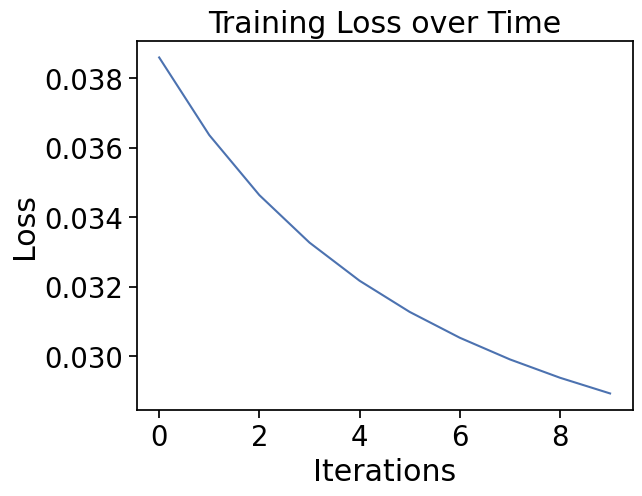

In [158]:
import matplotlib.pyplot as plt

plt.plot(loss_history)
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Training Loss over Time")
plt.show()

### Evaluate network on test data

In [159]:
def evaluation(params, tst_set):
  w0 = params[0]
  bh = params[1]
  w1 = params[2]
  bo = params[3]

  # First layer propagation
  zh = np.dot(tst_set, w0) + bh
  layer1 = sigmoid(zh)

  # Second layer propagation
  zo = np.dot(layer1, w1) + bo
  layer2 = softmax(zo)

  return layer2.argmax(axis=1)  # Convert to class labels


In [160]:
y_pred = evaluation(trainedNet, X_test)


In [161]:
y_actual = pd.Series(y_test.argmax(axis=1))
y_pred = pd.Series(y_pred) 

cm = pd.crosstab(y_actual, y_pred).to_numpy()
cm

array([[14,  0,  0],
       [ 0, 13,  3],
       [ 0,  0, 15]], dtype=int64)

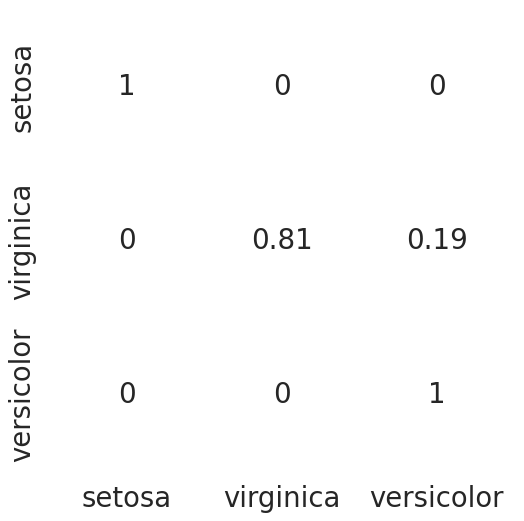

In [130]:
if cm.shape[1]<3:
  cm = np.concatenate((cm,np.zeros((3,3-cm.shape[1]))),axis=1)

cm_norm = np.array([cm[i][j]/cm[i].sum() for i in range(cm.shape[0]) for j in range(cm.shape[1])])
cm_norm = cm_norm.reshape(3,3)


import seaborn as sns
from matplotlib.colors import ListedColormap


df_cm = pd.DataFrame(cm_norm, index = ['setosa','virginica','versicolor'],
                  columns = ['setosa','virginica','versicolor'])

plt.figure(figsize = (6,6))

with sns.axes_style('white'):
    sns.heatmap(df_cm,
                cbar=False,
                square=False,
                annot=True,
                annot_kws={"size": 20},
                cmap=ListedColormap(['white']),
                linewidths=0.5)
    sns.set(font_scale=1.8)